In [6]:
# 分析 CPU Preload 对不同 RR 和 Chunk Size 的性能影响
# 日志目录: project-chunk-weight-loading-test-low-high-rate

import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

# 设置绘图风格
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 11

# 定义日志目录
logs_dir = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-chunk-weight-loading-test-low-high-rate")

def extract_params_from_dirname(dirname):
    """从目录名中提取参数"""
    params = {}
    # 提取chunk
    chunk_match = re.search(r'\{chunk=(\d+)\}', dirname)
    if chunk_match:
        params['chunk'] = float(chunk_match.group(1))
    # 提取rr
    rr_match = re.search(r'\{rr=([\d.]+)\}', dirname)
    if rr_match:
        params['rr'] = float(rr_match.group(1))
    # 提取cpu_cache
    cpu_cache_match = re.search(r'\{cpu_cache=(\d)\}', dirname)
    if cpu_cache_match:
        params['cpu_cache'] = int(cpu_cache_match.group(1))
    return params

def extract_benchmark_metrics(benchmark_log_file):
    """从benchmark.log中提取聚合统计指标"""
    metrics = {}
    
    try:
        with open(benchmark_log_file, 'r', errors='ignore') as f:
            content = f.read()
        
        # TTFT (毫秒)
        ttft_match = re.search(r'Mean TTFT \(ms\):\s+([\d.]+)', content)
        if ttft_match:
            metrics['ttft_ms'] = float(ttft_match.group(1))
        
        # Normalized Latency (ms/tok)
        norm_lat_match = re.search(r'Mean Normalized Latency \(ms/tok\):\s+([\d.]+)', content)
        if norm_lat_match:
            metrics['normalized_latency_ms_tok'] = float(norm_lat_match.group(1))
        
        # Throughput (tokens/s)
        throughput_match = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', content)
        if throughput_match:
            metrics['throughput_tokens_per_s'] = float(throughput_match.group(1))
            
    except Exception as e:
        print(f"Error parsing {benchmark_log_file}: {e}")
    
    return metrics

def extract_weight_loading_time(analysis_file):
    """从analysis.txt中提取weight loading time"""
    try:
        with open(analysis_file, 'r', errors='ignore') as f:
            content = f.read()
        
        # 匹配 "[Timeline] After Weight Loading" 后的 Average 值
        weight_match = re.search(
            r'\[Timeline\] After Weight Loading.*?Average:\s+([\d.]+)(s|ms)',
            content, re.DOTALL
        )
        if weight_match:
            value = float(weight_match.group(1))
            unit = weight_match.group(2)
            if unit == 'ms':
                value = value / 1000  # 转换为秒
            return value
    except Exception as e:
        print(f"Error parsing {analysis_file}: {e}")
    return None

# 收集所有数据
test_dirs = sorted([d for d in logs_dir.iterdir() if d.is_dir() and d.name.startswith('test-')])
print(f"找到 {len(test_dirs)} 个测试目录")

all_data = []
for test_dir in test_dirs:
    params = extract_params_from_dirname(test_dir.name)
    benchmark_file = test_dir / "benchmark.log"
    analysis_file = test_dir / "analysis.txt"
    
    if benchmark_file.exists():
        metrics = extract_benchmark_metrics(benchmark_file)
        
        # 提取 weight loading time
        if analysis_file.exists():
            wl_time = extract_weight_loading_time(analysis_file)
            if wl_time is not None:
                metrics['weight_loading_time_s'] = wl_time
        
        row = {**params, **metrics}
        all_data.append(row)

df = pd.DataFrame(all_data)
print(f"\n成功处理 {len(df)} 个测试")
print(f"\nDataFrame 列: {df.columns.tolist()}")
print(f"\n数据预览:")
print(df.to_string())

找到 26 个测试目录

成功处理 26 个测试

DataFrame 列: ['chunk', 'rr', 'cpu_cache', 'ttft_ms', 'normalized_latency_ms_tok', 'throughput_tokens_per_s', 'weight_loading_time_s']

数据预览:
    chunk   rr  cpu_cache  ttft_ms  normalized_latency_ms_tok  throughput_tokens_per_s  weight_loading_time_s
0    10.0  1.5          0   435.50                     190.75                   160.79                    6.6
1    10.0  1.5          1   422.64                     188.65                   152.50                    2.9
2   160.0  1.5          0   459.04                     195.52                   154.16                    6.3
3   160.0  1.5          1   437.60                     192.58                   151.59                    2.2
4    20.0  1.5          0   437.86                     192.10                   165.22                    6.6
5    20.0  1.5          1   444.85                     196.53                   153.06                    2.8
6    40.0  1.5          0   424.76                     189.13  

找到 6 个测试目录
成功提取 18 条 per-rep 数据

── Weight Loading Time Outlier 去除 (threshold: >1.5x median) ──
  chunk=  40, cpu=1: 去除 1 个 outlier (10.8s) | median=3.0s, 保留: 3.0s, 3.0s
  chunk=  80, cpu=1: 去除 1 个 outlier (7.8s) | median=2.9s, 保留: 2.6s, 2.9s

  共去除 2 个 weight loading outlier (总数据点: 18)

每个配置的有效 repetition 数 (去除 outlier 后):
  chunk=   1, cpu=1: 3 reps ✅, wl=[4.4s, 5.0s, 4.5s] (3 pts)
  chunk=   5, cpu=1: 3 reps ✅, wl=[2.8s, 3.0s, 3.5s] (3 pts)
  chunk=  20, cpu=1: 3 reps ✅, wl=[2.9s, 3.2s, 3.1s] (3 pts)
  chunk=  40, cpu=1: 3 reps ✅, wl=[3.0s, 3.0s] (2 pts)
  chunk=  80, cpu=1: 3 reps ✅, wl=[2.6s, 2.9s] (2 pts)
  chunk= 160, cpu=1: 3 reps ✅, wl=[2.6s, 2.6s, 2.8s] (3 pts)

聚合数据 (outlier removed for WL):
   chunk  cpu_cache   ttft_mean   ttft_std  norm_lat_mean  norm_lat_std  throughput_mean  throughput_std   wl_mean    wl_std
0      1          1  557.246667  42.786302     262.456667     11.930483       167.503333        2.371589  4.633333  0.321455
1      5          1  600.730000  27.75

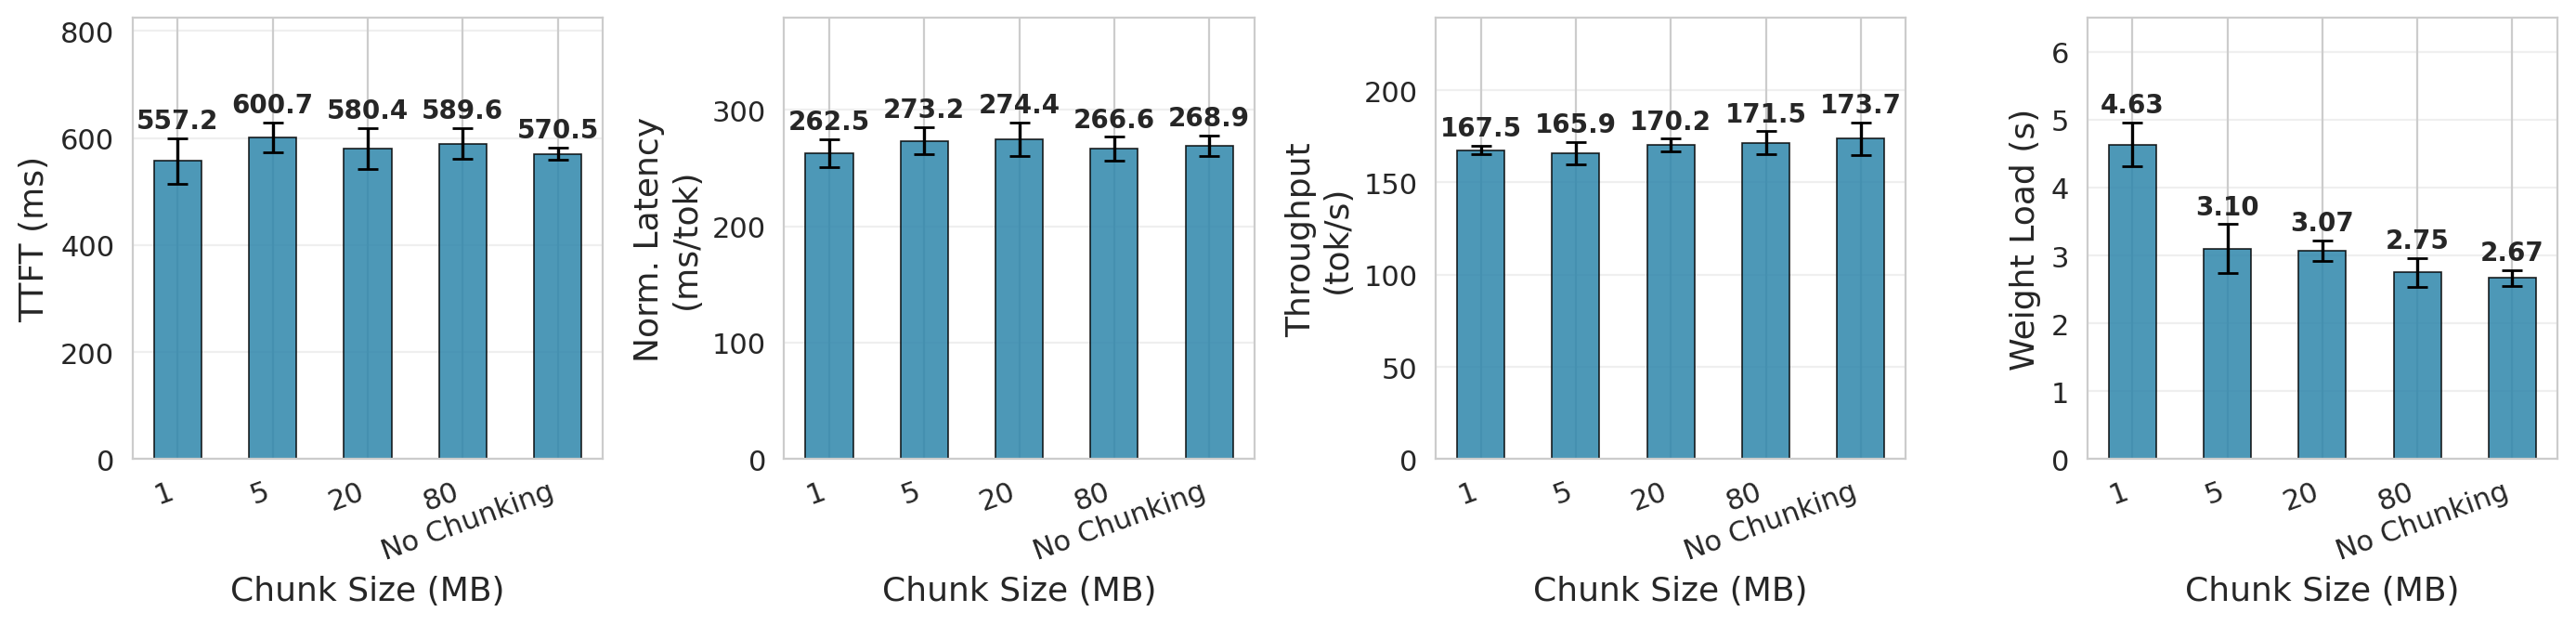

In [13]:
# 绘制 CPU Preload 对比图 (rep=3, 带标准差误差线, 可选去除 weight loading outlier)
# 数据来源: project-chunk-weight-loading-test-final (rr=2, rep=3)
# Outlier 处理: weight loading time 超过同组 median 1.5x 的 rep 被剔除

# ==================== 配置开关 ====================
REMOVE_OUTLIERS = True  # 设为 False 则保留所有数据点
# ==================================================

import os, re, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")

logs_dir_final = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-chunk-weight-loading-test-final-5")

def extract_params_from_dirname_v2(dirname):
    """从目录名中提取参数"""
    params = {}
    for key in ['chunk', 'rr', 'cpu_cache', 'rep']:
        match = re.search(rf'\{{{key}=([^}}]+)\}}', dirname)
        if match:
            params[key] = float(match.group(1)) if '.' in match.group(1) else int(match.group(1))
    return params

def extract_per_rep_metrics(benchmark_log_file):
    """从 benchmark.log 中提取每个 repetition 的指标"""
    rep_metrics = []
    try:
        with open(benchmark_log_file, 'r', errors='ignore') as f:
            content = f.read()
        
        rep_sections = re.split(r'#{10,}\s*REPETITION\s+\d+/\d+\s*#{10,}', content)
        
        for section in rep_sections[1:]:
            metrics = {}
            completed_match = re.search(r'Successful requests:\s+(\d+)', section)
            if completed_match:
                completed = int(completed_match.group(1))
                if completed == 0:
                    continue
            
            ttft_match = re.search(r'Mean TTFT \(ms\):\s+([\d.]+)', section)
            if ttft_match:
                metrics['ttft_ms'] = float(ttft_match.group(1))
            
            norm_lat = re.search(r'Mean Normalized Latency \(ms/tok\):\s+([\d.]+)', section)
            if norm_lat:
                metrics['normalized_latency_ms_tok'] = float(norm_lat.group(1))
            
            throughput = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', section)
            if throughput:
                metrics['throughput_tokens_per_s'] = float(throughput.group(1))
            
            if metrics:
                rep_metrics.append(metrics)
    except Exception as e:
        print(f"Error parsing {benchmark_log_file}: {e}")
    
    return rep_metrics

def extract_per_rep_weight_loading_from_server_log(server_log_file):
    """从 server.log 中提取每个 rep 的 rank0 weight loading 时间"""
    times = []
    try:
        with open(server_log_file, 'r', errors='ignore') as f:
            for line in f:
                if '[timeline]: after weight loading, time taken:' in line:
                    if ', ip=' in line:
                        continue
                    time_match = re.search(r'time taken:\s+([\d.]+)(s|ms)', line)
                    if time_match:
                        val = float(time_match.group(1))
                        if time_match.group(2) == 'ms':
                            val /= 1000
                        times.append(val)
    except Exception as e:
        print(f"Error parsing {server_log_file}: {e}")
    return times

# 收集所有数据 (per-rep)
all_rep_data = []
test_dirs = sorted([d for d in logs_dir_final.iterdir() if d.is_dir() and d.name.startswith('test-')])
print(f"找到 {len(test_dirs)} 个测试目录")

for test_dir in test_dirs:
    params = extract_params_from_dirname_v2(test_dir.name)
    benchmark_file = test_dir / "benchmark.log"
    server_log_file = test_dir / "server.log"
    
    if not benchmark_file.exists():
        continue
    
    rep_metrics_list = extract_per_rep_metrics(benchmark_file)
    
    wl_times = []
    if server_log_file.exists():
        wl_times = extract_per_rep_weight_loading_from_server_log(server_log_file)
    
    for rep_idx, metrics in enumerate(rep_metrics_list):
        row = {**params, 'rep_idx': rep_idx + 1, **metrics}
        if rep_idx < len(wl_times):
            row['weight_loading_time_s'] = wl_times[rep_idx]
        all_rep_data.append(row)

df_rep = pd.DataFrame(all_rep_data)
print(f"成功提取 {len(df_rep)} 条 per-rep 数据")

# ── Outlier 去除 (仅针对 weight loading time) ──
has_wl = 'weight_loading_time_s' in df_rep.columns and df_rep['weight_loading_time_s'].notna().any()

if REMOVE_OUTLIERS and has_wl:
    print("\n── Weight Loading Time Outlier 去除 (threshold: >1.5x median) ──")
    outlier_mask = pd.Series(False, index=df_rep.index)
    
    for (chunk, cpu), group in df_rep.groupby(['chunk', 'cpu_cache']):
        wl_vals = group['weight_loading_time_s'].dropna()
        if len(wl_vals) <= 1:
            continue
        median_val = wl_vals.median()
        threshold = 1.5 * median_val
        is_outlier = (group['weight_loading_time_s'] > threshold)
        n_outlier = is_outlier.sum()
        if n_outlier > 0:
            outlier_indices = group[is_outlier].index
            outlier_mask.loc[outlier_indices] = True
            outlier_vals = group.loc[is_outlier, 'weight_loading_time_s'].values
            normal_vals = group.loc[~is_outlier & group['weight_loading_time_s'].notna(), 'weight_loading_time_s'].values
            print(f"  chunk={int(chunk):>4}, cpu={int(cpu)}: 去除 {n_outlier} 个 outlier "
                  f"({', '.join(f'{v:.1f}s' for v in outlier_vals)}) | "
                  f"median={median_val:.1f}s, 保留: {', '.join(f'{v:.1f}s' for v in normal_vals)}")
    
    # 创建 cleaned 版本: outlier 的 weight loading 设为 NaN，其他指标保留
    df_rep_clean = df_rep.copy()
    df_rep_clean.loc[outlier_mask, 'weight_loading_time_s'] = np.nan
    
    total_removed = outlier_mask.sum()
    print(f"\n  共去除 {total_removed} 个 weight loading outlier (总数据点: {df_rep['weight_loading_time_s'].notna().sum()})")
else:
    df_rep_clean = df_rep.copy()
    if not REMOVE_OUTLIERS:
        print("\n── Outlier 去除已禁用 (REMOVE_OUTLIERS=False) ──")

# 检查每个配置的有效 rep 数
print("\n每个配置的有效 repetition 数 (去除 outlier 后):")
for (chunk, cpu), group in df_rep_clean.groupby(['chunk', 'cpu_cache']):
    n = len(group)
    n_wl = group['weight_loading_time_s'].notna().sum() if has_wl else 0
    wl_vals = group['weight_loading_time_s'].dropna().values if has_wl else []
    status = "✅" if n >= 2 else f"⚠️ ({n})"
    wl_str = f", wl=[{', '.join(f'{v:.1f}s' for v in wl_vals)}] ({n_wl} pts)" if len(wl_vals) > 0 else ""
    print(f"  chunk={int(chunk):>4}, cpu={int(cpu)}: {n} reps {status}{wl_str}")

# 按 chunk + cpu_cache 计算 mean 和 std (benchmark 指标用原始数据，weight loading 用 cleaned)
agg_dict = {
    'ttft_mean': ('ttft_ms', 'mean'),
    'ttft_std': ('ttft_ms', 'std'),
    'norm_lat_mean': ('normalized_latency_ms_tok', 'mean'),
    'norm_lat_std': ('normalized_latency_ms_tok', 'std'),
    'throughput_mean': ('throughput_tokens_per_s', 'mean'),
    'throughput_std': ('throughput_tokens_per_s', 'std'),
}
df_agg = df_rep.groupby(['chunk', 'cpu_cache']).agg(**agg_dict).reset_index()

# Weight loading 单独用 cleaned 数据聚合
if has_wl:
    wl_agg = df_rep_clean.groupby(['chunk', 'cpu_cache']).agg(
        wl_mean=('weight_loading_time_s', 'mean'),
        wl_std=('weight_loading_time_s', 'std')
    ).reset_index()
    df_agg = df_agg.merge(wl_agg, on=['chunk', 'cpu_cache'], how='left')
else:
    df_agg['wl_mean'] = np.nan
    df_agg['wl_std'] = np.nan

print("\n聚合数据 (outlier removed for WL):")
print(df_agg.to_string())

# ── 绘图 (仅CPU Preload) ──
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 200

target_chunks = [1, 5, 20, 80, 160]
df_cpu = df_agg[df_agg['cpu_cache'] == 1].sort_values('chunk')
df_cpu = df_cpu[df_cpu['chunk'].isin(target_chunks)]
available_chunks = [int(c) for c in sorted(df_cpu['chunk'].unique().tolist())]

x_labels = ['No Chunking' if c == 160 else str(c) for c in available_chunks]

metrics_to_plot = [
    ('ttft',       'TTFT (ms)'),
    ('norm_lat',   'Norm. Latency\n(ms/tok)'),
    ('throughput', 'Throughput\n(tok/s)'),
    ('wl',         'Weight Load (s)'),
]

bar_color = '#2E86AB'
bar_width = 0.5

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 3.5))

for col_idx, (prefix, metric_label) in enumerate(metrics_to_plot):
    ax = axes[col_idx]
    mean_col = f'{prefix}_mean'
    std_col  = f'{prefix}_std'

    if mean_col not in df_cpu.columns or df_cpu[mean_col].isna().all():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    vals = df_cpu[mean_col].values
    errs = df_cpu[std_col].fillna(0).values
    x = np.arange(len(available_chunks))

    bars = ax.bar(x, vals, bar_width,
                  yerr=errs, capsize=4, error_kw={'linewidth': 1.2},
                  color=bar_color, alpha=0.85, edgecolor='black', linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11, rotation=20, ha='right')
    ax.set_xlabel('Chunk Size (MB)', fontsize=13)
    ax.set_ylabel(metric_label, fontsize=13)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(top=ax.get_ylim()[1] * 1.25)

    for bar, err in zip(bars, errs):
        h = bar.get_height()
        fmt = f'{h:.1f}' if h >= 10 else f'{h:.2f}'
        ax.text(bar.get_x() + bar.get_width() / 2., h + err + 0.01 * ax.get_ylim()[1],
                fmt, ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

out_pdf = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-chunk-weight-loading-rep3.pdf'
out_png = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-chunk-weight-loading-rep3.png'
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f"\n已保存: {out_pdf}")
print(f"已保存: {out_png}")
plt.show()

从 project-chunk-weight-loading-test-final 找到 10 个测试目录


从 project-chunk-weight-loading-test-final-2 找到 12 个测试目录

成功提取 90 条 per-rep 数据
共去除 20 个 weight loading outlier

聚合数据:
    chunk  cpu_cache  ttft_mean   ttft_std  norm_lat_mean  norm_lat_std  throughput_mean  throughput_std   wl_mean    wl_std
0       1          0  589.88375  13.165905      320.03375      8.231542        194.48875        4.258170  7.783333  0.132916
1       1          1  586.54500  40.295073      317.67375     14.965450        199.87750        5.711419  4.671429  0.179947
2       5          0  600.47875  33.712498      323.00875     12.651806        194.46250        5.624746  6.980000  0.408656
3       5          1  573.88000  39.980799      317.15625     17.533293        193.94625        3.655047  3.220000  0.148324
4      20          0  594.21500  43.138093      317.40500     14.074904        197.34875        3.487977  7.083333  0.132916
5      20          1  583.29500  18.264610      319.92250      9.611172        194.17750        4.186273  2.828571  0.262769
6      4

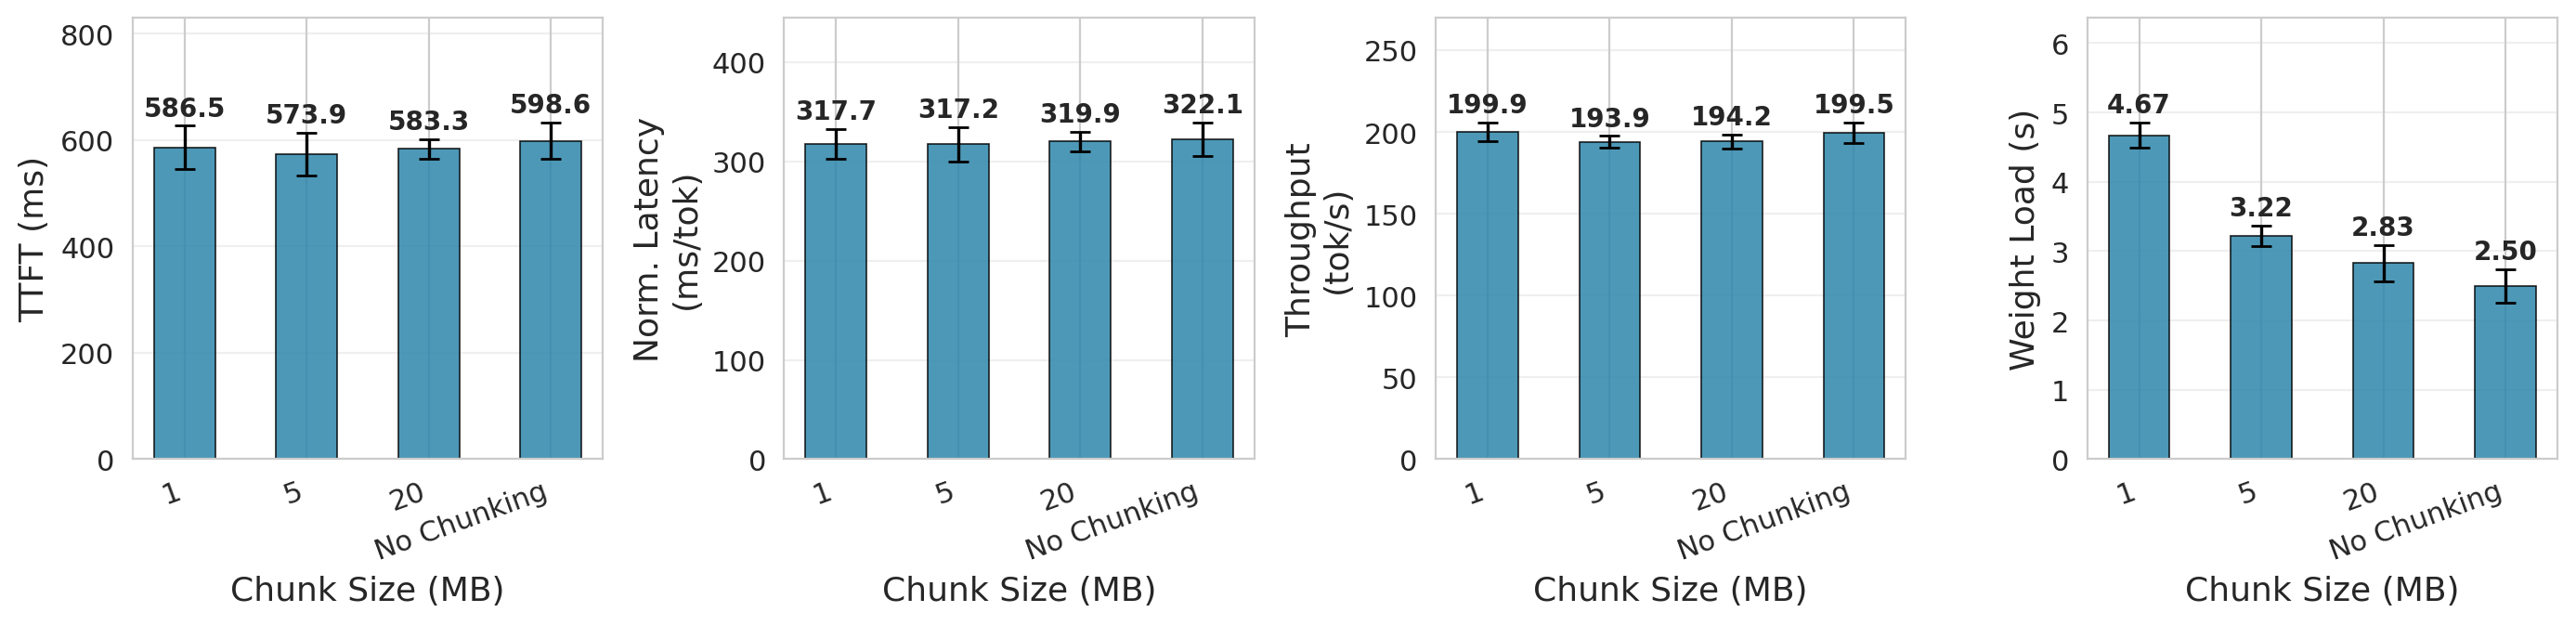

In [ ]:
# 合并两组实验数据 (rep=3 + rep=5 = 8次实验)
# 数据来源: project-chunk-weight-loading-test-final (rep=3) + project-chunk-weight-loading-test-final-2 (rep=5)
# Outlier 处理: weight loading time 超过同组 median 1.5x 的 rep 被剔除

# ==================== 配置开关 ====================
REMOVE_OUTLIERS = True  # 设为 False 则保留所有数据点
# ==================================================

import os, re, json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams['figure.dpi'] = 200

# 两个数据源目录
logs_dirs = [
    Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-chunk-weight-loading-test-final"),
    Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-chunk-weight-loading-test-final-2"),
]

def extract_params_from_dirname_v2(dirname):
    params = {}
    for key in ['chunk', 'rr', 'cpu_cache', 'rep']:
        match = re.search(rf'\{{{key}=([^}}]+)\}}', dirname)
        if match:
            params[key] = float(match.group(1)) if '.' in match.group(1) else int(match.group(1))
    return params

def extract_per_rep_metrics(benchmark_log_file):
    rep_metrics = []
    try:
        with open(benchmark_log_file, 'r', errors='ignore') as f:
            content = f.read()
        rep_sections = re.split(r'#{10,}\s*REPETITION\s+\d+/\d+\s*#{10,}', content)
        for section in rep_sections[1:]:
            metrics = {}
            completed_match = re.search(r'Successful requests:\s+(\d+)', section)
            if completed_match and int(completed_match.group(1)) == 0:
                continue
            ttft_match = re.search(r'Mean TTFT \(ms\):\s+([\d.]+)', section)
            if ttft_match:
                metrics['ttft_ms'] = float(ttft_match.group(1))
            norm_lat = re.search(r'Mean Normalized Latency \(ms/tok\):\s+([\d.]+)', section)
            if norm_lat:
                metrics['normalized_latency_ms_tok'] = float(norm_lat.group(1))
            throughput = re.search(r'Output token throughput \(tok/s\):\s+([\d.]+)', section)
            if throughput:
                metrics['throughput_tokens_per_s'] = float(throughput.group(1))
            if metrics:
                rep_metrics.append(metrics)
    except Exception as e:
        print(f"Error parsing {benchmark_log_file}: {e}")
    return rep_metrics

def extract_per_rep_weight_loading_from_server_log(server_log_file):
    times = []
    try:
        with open(server_log_file, 'r', errors='ignore') as f:
            for line in f:
                if '[timeline]: after weight loading, time taken:' in line:
                    if ', ip=' in line:
                        continue
                    time_match = re.search(r'time taken:\s+([\d.]+)(s|ms)', line)
                    if time_match:
                        val = float(time_match.group(1))
                        if time_match.group(2) == 'ms':
                            val /= 1000
                        times.append(val)
    except Exception as e:
        print(f"Error parsing {server_log_file}: {e}")
    return times

# 收集数据
all_rep_data = []
total_dirs = 0
for logs_dir in logs_dirs:
    test_dirs = sorted([d for d in logs_dir.iterdir() if d.is_dir() and d.name.startswith('test-')])
    total_dirs += len(test_dirs)
    source_name = logs_dir.name
    print(f"从 {source_name} 找到 {len(test_dirs)} 个测试目录")
    for test_dir in test_dirs:
        params = extract_params_from_dirname_v2(test_dir.name)
        benchmark_file = test_dir / "benchmark.log"
        server_log_file = test_dir / "server.log"
        if not benchmark_file.exists():
            continue
        rep_metrics_list = extract_per_rep_metrics(benchmark_file)
        wl_times = extract_per_rep_weight_loading_from_server_log(server_log_file) if server_log_file.exists() else []
        for rep_idx, metrics in enumerate(rep_metrics_list):
            row = {**params, 'rep_idx': rep_idx + 1, 'source': source_name, **metrics}
            if rep_idx < len(wl_times):
                row['weight_loading_time_s'] = wl_times[rep_idx]
            all_rep_data.append(row)

df_rep = pd.DataFrame(all_rep_data)
print(f"\n成功提取 {len(df_rep)} 条 per-rep 数据")

# Outlier 去除
has_wl = 'weight_loading_time_s' in df_rep.columns and df_rep['weight_loading_time_s'].notna().any()

if REMOVE_OUTLIERS and has_wl:
    outlier_mask = pd.Series(False, index=df_rep.index)
    for (chunk, cpu), group in df_rep.groupby(['chunk', 'cpu_cache']):
        wl_vals = group['weight_loading_time_s'].dropna()
        if len(wl_vals) <= 1:
            continue
        median_val = wl_vals.median()
        is_outlier = group['weight_loading_time_s'] > 1.5 * median_val
        if is_outlier.sum() > 0:
            outlier_mask.loc[group[is_outlier].index] = True
    df_rep_clean = df_rep.copy()
    df_rep_clean.loc[outlier_mask, 'weight_loading_time_s'] = np.nan
    print(f"共去除 {outlier_mask.sum()} 个 weight loading outlier")
else:
    df_rep_clean = df_rep.copy()
    if not REMOVE_OUTLIERS:
        print("── Outlier 去除已禁用 (REMOVE_OUTLIERS=False) ──")

# 聚合
agg_dict = {
    'ttft_mean': ('ttft_ms', 'mean'), 'ttft_std': ('ttft_ms', 'std'),
    'norm_lat_mean': ('normalized_latency_ms_tok', 'mean'), 'norm_lat_std': ('normalized_latency_ms_tok', 'std'),
    'throughput_mean': ('throughput_tokens_per_s', 'mean'), 'throughput_std': ('throughput_tokens_per_s', 'std'),
}
df_agg = df_rep.groupby(['chunk', 'cpu_cache']).agg(**agg_dict).reset_index()
if has_wl:
    wl_agg = df_rep_clean.groupby(['chunk', 'cpu_cache']).agg(
        wl_mean=('weight_loading_time_s', 'mean'), wl_std=('weight_loading_time_s', 'std')
    ).reset_index()
    df_agg = df_agg.merge(wl_agg, on=['chunk', 'cpu_cache'], how='left')
else:
    df_agg['wl_mean'] = np.nan
    df_agg['wl_std'] = np.nan

print("\n聚合数据:")
print(df_agg.to_string())

# ── 绘图 (仅CPU Preload) ──
target_chunks = [1, 5, 20, 160]
df_cpu = df_agg[df_agg['cpu_cache'] == 1].sort_values('chunk')
df_cpu = df_cpu[df_cpu['chunk'].isin(target_chunks)]
available_chunks = sorted(df_cpu['chunk'].unique().tolist())

# x轴标签：160 改为 "No Chunking"
x_labels = ['No Chunking' if int(c) == 160 else str(int(c)) for c in available_chunks]

metrics_to_plot = [
    ('ttft',       'TTFT (ms)'),
    ('norm_lat',   'Norm. Latency\n(ms/tok)'),
    ('throughput', 'Throughput\n(tok/s)'),
    ('wl',         'Weight Load (s)'),
]

bar_color = '#2E86AB'
bar_width = 0.5

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(14, 3.5))

for col_idx, (prefix, metric_label) in enumerate(metrics_to_plot):
    ax = axes[col_idx]
    mean_col = f'{prefix}_mean'
    std_col  = f'{prefix}_std'

    if mean_col not in df_cpu.columns or df_cpu[mean_col].isna().all():
        ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
        continue

    vals = df_cpu[mean_col].values
    errs = df_cpu[std_col].fillna(0).values
    x = np.arange(len(available_chunks))

    bars = ax.bar(x, vals, bar_width,
                  yerr=errs, capsize=4, error_kw={'linewidth': 1.2},
                  color=bar_color, alpha=0.85, edgecolor='black', linewidth=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, fontsize=11, rotation=20, ha='right')
    ax.set_xlabel('Chunk Size (MB)', fontsize=13)
    ax.set_ylabel(metric_label, fontsize=13)
    ax.tick_params(axis='y', labelsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(top=ax.get_ylim()[1] * 1.25)

    for bar, err in zip(bars, errs):
        h = bar.get_height()
        fmt = f'{h:.1f}' if h >= 10 else f'{h:.2f}'
        ax.text(bar.get_x() + bar.get_width() / 2., h + err + 0.01 * ax.get_ylim()[1],
                fmt, ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

out_pdf = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-chunk-weight-loading.pdf'
out_png = '/home/bxb1/vllm_workbench/vllm/SOSP-Paper-Xu-Bai-/Figures/eval-chunk-weight-loading.png'
plt.savefig(out_pdf, format='pdf', bbox_inches='tight')
plt.savefig(out_png, dpi=300, bbox_inches='tight')
print(f"\n已保存: {out_pdf}")
print(f"已保存: {out_png}")
plt.show()

找到的测试目录 (RR=2.0, cpu_cache=0):
  Chunk=5:   test-{kernel=direct}-{pp=40-40}-{rr=2}-{mig=1}-{in=512}-{out=16}-{n_req=200}-{rep=10}-{chunk=5}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=0}
  Chunk=160: test-{kernel=direct}-{pp=40-40}-{rr=2}-{mig=1}-{in=512}-{out=16}-{n_req=200}-{rep=10}-{chunk=160}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=0}

分析 Chunk=5 的 server.log...
Analyzing log file: /home/bxb1/vllm_workbench/vllm/new-logs/project-chunk-weight-loading-test-final-3/test-{kernel=direct}-{pp=40-40}-{rr=2}-{mig=1}-{in=512}-{out=16}-{n_req=200}-{rep=10}-{chunk=5}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=0}/server.log


Finished parsing log file.

  ✓ 分析完成

分析 Chunk=160 的 server.log...
Analyzing log file: /home/bxb1/vllm_workbench/vllm/new-logs/project-chunk-weight-loading-test-final-3/test-{kernel=direct}-{pp=40-40}-{rr=2}-{mig=1}-{in=512}-{out=16}-{n_req=200}-{rep=10}-{chunk=160}-{mig_mode=async}-{blk=128}-{vmm=1}-{kv_resize=1}-{cpu_cache=0}/server.log
Finished parsing log file.

  ✓ 分析完成

成功分析 2 个日志文件
Process Engine Step Time:
  Chunk=5: 36113 个数据点
  Chunk=160: 36225 个数据点
After Forwarding Took:
  Chunk=5: 36100 个数据点
  Chunk=160: 36213 个数据点
Communication Time from Upstream:
  Chunk=5: 18050 个数据点
  Chunk=160: 18106 个数据点

Chunk=5 Migration 边界: start=241, wl_start=244, wl_end=334, end=32860

Chunk=160 Migration 边界: start=243, wl_start=246, wl_end=290, end=32589

最大 migration 长度: 32619 steps

已保存: chunk_5_vs_160_rr2_server_metrics_aligned.png


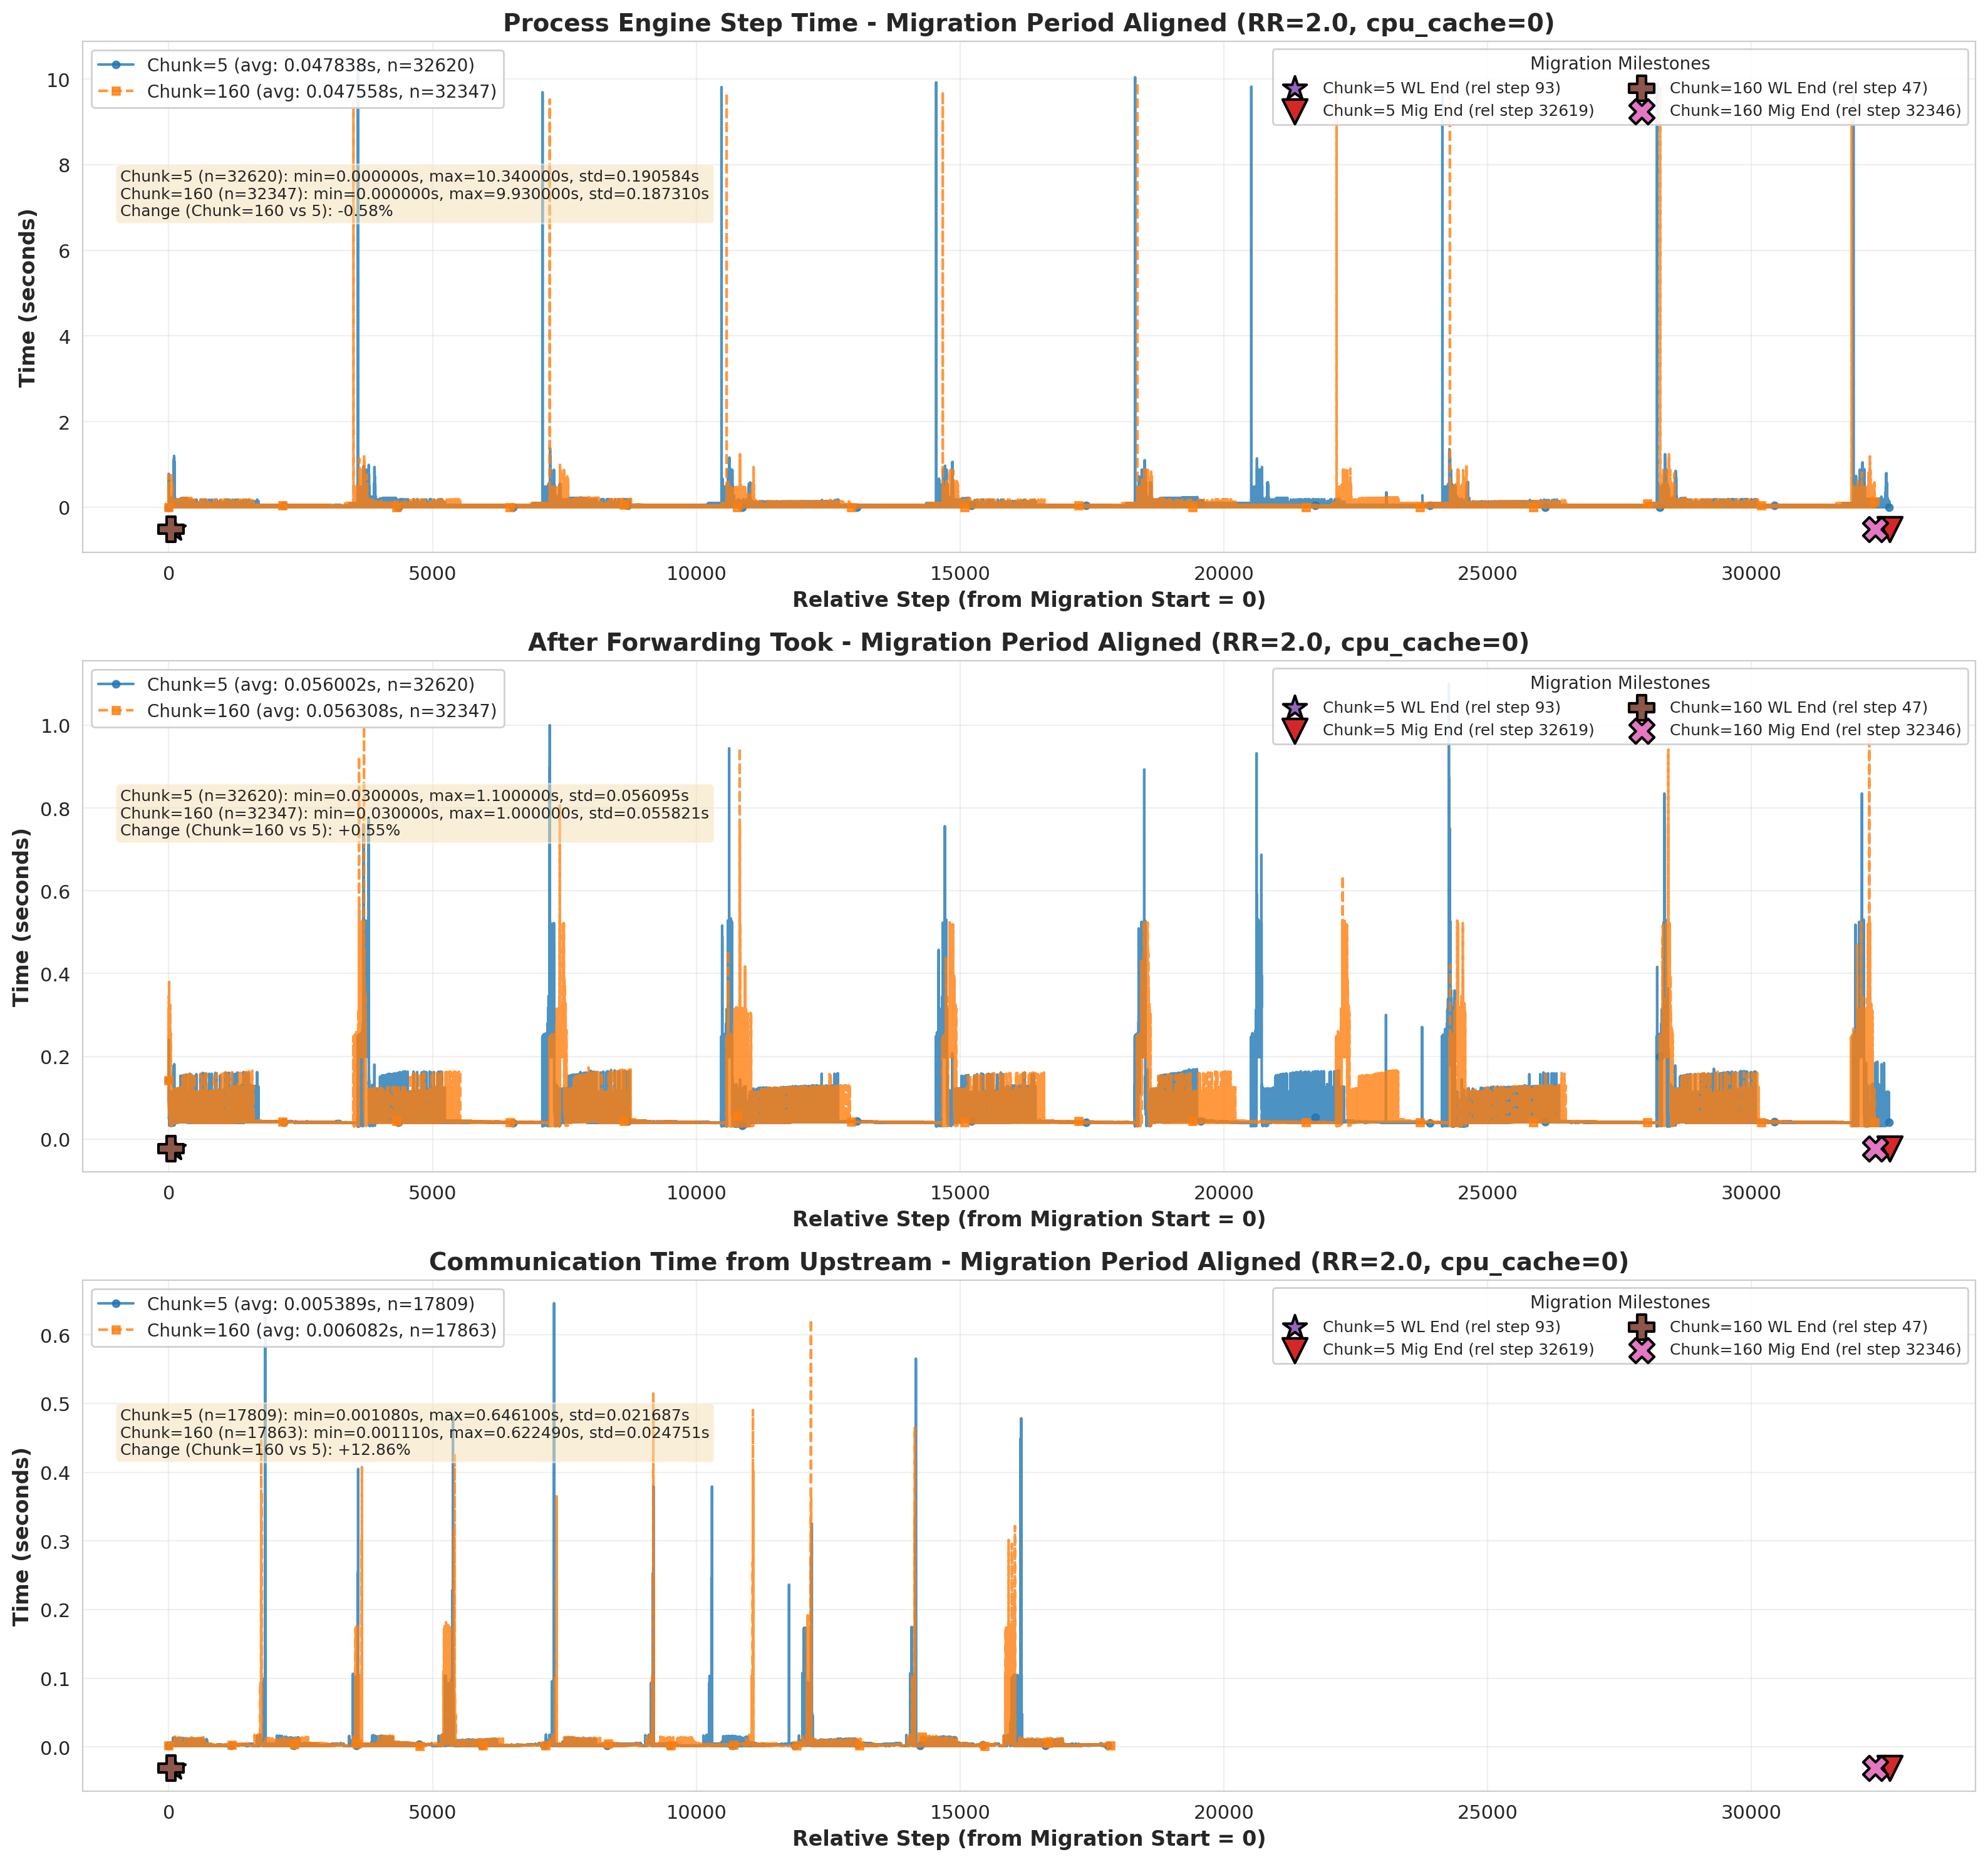


详细统计 (RR=2.0, cpu_cache=0)

Process Engine Step Time:
  Chunk=5: mean=0.047303s, median=0.040000s
  Chunk=160: mean=0.046928s, median=0.040000s

After Forwarding Took:
  Chunk=5: mean=0.055873s, median=0.042000s
  Chunk=160: mean=0.056014s, median=0.042000s

Communication Time from Upstream:
  Chunk=5: mean=0.005569s, median=0.002490s
  Chunk=160: mean=0.006199s, median=0.002380s


In [ ]:
# RR=2.0 时 Chunk=5 vs Chunk=160 的 After Forwarding 和 Process Engine Step Time 对比
# 数据来源: project-chunk-weight-loading-test-low-high-rate

import os
import re
import sys
import importlib
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, '/home/bxb1/vllm_workbench/vllm/vllm_exp')

# 加载日志分析工具
import log_analysing_tools.analyze_log_metrics as alm
importlib.reload(alm)
from log_analysing_tools.analyze_log_metrics import LogMetricsAnalyzer, METRIC_CONFIGS

def extract_params_from_dirname(dirname):
    """从目录名中提取参数"""
    params = {}
    chunk_match = re.search(r'\{chunk=(\d+)\}', dirname)
    if chunk_match:
        params['chunk'] = float(chunk_match.group(1))
    rr_match = re.search(r'\{rr=([\d.]+)\}', dirname)
    if rr_match:
        params['rr'] = float(rr_match.group(1))
    cpu_cache_match = re.search(r'\{cpu_cache=(\d)\}', dirname)
    if cpu_cache_match:
        params['cpu_cache'] = int(cpu_cache_match.group(1))
    return params

# 日志目录
logs_dir_rr2 = Path("/home/bxb1/vllm_workbench/vllm/new-logs/project-chunk-weight-loading-test-final-3")

# 找到 RR=2.0, cpu_cache=0 的 chunk=5 和 chunk=160 目录
chunk_5_dir_rr2 = None
chunk_160_dir_rr2 = None

for test_dir in logs_dir_rr2.iterdir():
    if not test_dir.is_dir() or not test_dir.name.startswith('test-'):
        continue
    params = extract_params_from_dirname(test_dir.name)
    if params.get('rr') == 2.0 and params.get('cpu_cache') == 0:
        if params.get('chunk') == 5:
            chunk_5_dir_rr2 = test_dir
        elif params.get('chunk') == 160:
            chunk_160_dir_rr2 = test_dir

print("找到的测试目录 (RR=2.0, cpu_cache=0):")
print(f"  Chunk=5:   {chunk_5_dir_rr2.name if chunk_5_dir_rr2 else '未找到'}")
print(f"  Chunk=160: {chunk_160_dir_rr2.name if chunk_160_dir_rr2 else '未找到'}")

# 分析 server.log 文件
log_dirs_rr2 = {}
labels_rr2 = {}
analyzers_rr2 = {}

if chunk_5_dir_rr2:
    log_dirs_rr2['chunk_5'] = chunk_5_dir_rr2
    labels_rr2['chunk_5'] = 'Chunk=5'
    log_file = chunk_5_dir_rr2 / 'server.log'
    if log_file.exists():
        print(f"\n分析 Chunk=5 的 server.log...")
        analyzers_rr2['chunk_5'] = LogMetricsAnalyzer(str(log_file))
        analyzers_rr2['chunk_5'].analyze_file()
        print(f"  ✓ 分析完成")

if chunk_160_dir_rr2:
    log_dirs_rr2['chunk_160'] = chunk_160_dir_rr2
    labels_rr2['chunk_160'] = 'Chunk=160'
    log_file = chunk_160_dir_rr2 / 'server.log'
    if log_file.exists():
        print(f"\n分析 Chunk=160 的 server.log...")
        analyzers_rr2['chunk_160'] = LogMetricsAnalyzer(str(log_file))
        analyzers_rr2['chunk_160'].analyze_file()
        print(f"  ✓ 分析完成")

print(f"\n成功分析 {len(analyzers_rr2)} 个日志文件")

# 辅助函数
def parse_time_to_seconds(time_str):
    """将时间字符串转换为秒"""
    time_str = time_str.strip()
    match = re.match(r'([0-9.eE+-]+)\s*(µs|ms|seconds?|s)', time_str)
    if match:
        value = float(match.group(1))
        unit = match.group(2)
        if unit in ['µs']:
            return value / 1_000_000
        elif unit == 'ms':
            return value / 1000
        elif unit in ['seconds', 'second', 's']:
            return value
    return 0

def extract_time_series_from_metric(metric_data, metric_type="list"):
    """从 metric 数据中提取时间序列"""
    if not metric_data:
        return []
    values = []
    if metric_type == "keyed_dict":
        for layer_id, time_strings in metric_data.items():
            for time_str in time_strings:
                values.append(parse_time_to_seconds(time_str))
    else:
        for time_str in metric_data:
            values.append(parse_time_to_seconds(time_str))
    return values

def detect_migration_boundaries(server_log_path):
    """从 server.log 中检测 migration 的开始和结束位置"""
    migration_start_step = None
    weight_loading_start_step = None
    weight_loading_end_step = None
    migration_end_step = None
    
    try:
        with open(server_log_path, 'r', errors='ignore') as f:
            content = f.read()
        lines = content.split('\n')
        
        engine_step_lines = []
        for i, line in enumerate(lines, 1):
            if 'process the engine step, time:' in line:
                engine_step_lines.append(i)
        
        # 找到 migration 开始: "Using async migration mode"
        migration_start_line = None
        for i, line in enumerate(lines, 1):
            if 'Using async migration mode' in line or 'migration_thread: current alternative_configs' in line:
                migration_start_line = i
                break
        
        # 找到 weight loading 开始
        weight_loading_start_line = None
        for i, line in enumerate(lines, 1):
            if 'before weight loading' in line:
                weight_loading_start_line = i
                break
        
        # 找到 weight loading 结束: "after weight loading"
        weight_loading_end_line = None
        for i, line in enumerate(lines, 1):
            if 'after weight loading' in line.lower():
                weight_loading_end_line = i
                break
        
        # 找到 migration 真正结束: "commit ptr tables after migration" 是最终标志
        migration_end_line = None
        for i, line in enumerate(lines, 1):
            if 'commit ptr tables after migration' in line:
                migration_end_line = i
        
        # 如果没找到 commit ptr tables，回退到 after weight loading
        if migration_end_line is None:
            for i, line in enumerate(lines, 1):
                if 'after weight loading' in line.lower():
                    migration_end_line = i
        
        # 转换行号为 step 号
        if migration_start_line and engine_step_lines:
            for step_idx, line_num in enumerate(engine_step_lines):
                if line_num > migration_start_line:
                    migration_start_step = step_idx
                    break
        
        if weight_loading_start_line and engine_step_lines:
            for step_idx, line_num in enumerate(engine_step_lines):
                if line_num > weight_loading_start_line:
                    weight_loading_start_step = step_idx
                    break
        
        if weight_loading_end_line and engine_step_lines:
            for step_idx, line_num in enumerate(engine_step_lines):
                if line_num > weight_loading_end_line:
                    weight_loading_end_step = step_idx
                    break
        
        if migration_end_line and engine_step_lines:
            for step_idx, line_num in enumerate(engine_step_lines):
                if line_num > migration_end_line:
                    migration_end_step = step_idx
                    break
            if migration_end_step is None:
                migration_end_step = len(engine_step_lines) - 1
                
    except Exception as e:
        print(f"Error detecting migration boundaries: {e}")
    
    return migration_start_step, weight_loading_start_step, weight_loading_end_step, migration_end_step

# 要绘制的 metrics
target_metrics_rr2 = [
    'Process Engine Step Time',
    'After Forwarding Took',
    'Communication Time from Upstream',
]

# 提取时间序列数据
metric_time_series_rr2 = {}

for config in METRIC_CONFIGS:
    if config.display_name in target_metrics_rr2:
        metric_name = config.name
        display_name = config.display_name
        metric_time_series_rr2[display_name] = {}
        
        for key, analyzer in analyzers_rr2.items():
            data = analyzer.metrics.get(metric_name)
            metric_time_series_rr2[display_name][key] = extract_time_series_from_metric(
                data, config.metric_type.value
            )
        
        print(f"{display_name}:")
        for key in analyzers_rr2.keys():
            n_points = len(metric_time_series_rr2[display_name].get(key, []))
            print(f"  {labels_rr2[key]}: {n_points} 个数据点")

# 检测 migration 边界
migration_boundaries_rr2 = {}
for key, dir_path in log_dirs_rr2.items():
    server_log = dir_path / 'server.log'
    if server_log.exists():
        mig_start, wl_start, wl_end, mig_end = detect_migration_boundaries(str(server_log))
        migration_boundaries_rr2[key] = {
            'migration_start': mig_start,
            'weight_loading_start': wl_start,
            'weight_loading_end': wl_end,
            'migration_end': mig_end
        }
        print(f"\n{labels_rr2[key]} Migration 边界: start={mig_start}, wl_start={wl_start}, wl_end={wl_end}, end={mig_end}")

# 绘制 Time Series 对比图 (x轴对齐，从 migration start=0 开始)
fig, axes = plt.subplots(len(target_metrics_rr2), 1, figsize=(16, 5 * len(target_metrics_rr2)))
if len(target_metrics_rr2) == 1:
    axes = [axes]

data_colors = ['#1f77b4', '#ff7f0e']
line_styles = ['-', '--']
plot_markers = ['o', 's']

# X轴marker样式定义 (相对位置)
xaxis_markers = {
    'chunk_5': {'wl_end': ('*', '#9467bd', 'Chunk=5 WL End'), 'end': ('v', '#d62728', 'Chunk=5 Mig End')},
    'chunk_160': {'wl_end': ('P', '#8c564b', 'Chunk=160 WL End'), 'end': ('X', '#e377c2', 'Chunk=160 Mig End')}
}

# 计算最大 migration 长度用于 x 轴范围
max_migration_length = 0
for bounds in migration_boundaries_rr2.values():
    if bounds['migration_start'] and bounds['migration_end']:
        length = bounds['migration_end'] - bounds['migration_start']
        max_migration_length = max(max_migration_length, length)
print(f"\n最大 migration 长度: {max_migration_length} steps")

for idx, metric_name in enumerate(target_metrics_rr2):
    ax = axes[idx]
    
    if metric_name not in metric_time_series_rr2:
        ax.text(0.5, 0.5, f'No data for {metric_name}', ha='center', va='center', transform=ax.transAxes)
        continue
    
    stats_lines = []
    avg_values = {}
    relative_bounds = {}  # 存储相对位置的边界
    
    for i, key in enumerate(log_dirs_rr2.keys()):
        full_data = metric_time_series_rr2[metric_name].get(key, [])[1:]  # Skip first point
        
        if full_data and key in migration_boundaries_rr2:
            bounds = migration_boundaries_rr2[key]
            mig_start = bounds['migration_start'] - 1 if bounds['migration_start'] else 0
            mig_end = bounds['migration_end'] - 1 if bounds['migration_end'] else len(full_data)
            wl_end = bounds['weight_loading_end'] - 1 if bounds['weight_loading_end'] else None
            
            # 截取 migration 期间的数据
            mig_data = full_data[max(0, mig_start):min(len(full_data), mig_end + 1)]
            
            if mig_data:
                # x 轴从 0 开始（相对于 migration start）
                relative_steps = list(range(len(mig_data)))
                
                # 计算相对位置的边界
                rel_wl_end = (wl_end - mig_start) if wl_end is not None else None
                rel_mig_end = mig_end - mig_start
                relative_bounds[key] = {'wl_end': rel_wl_end, 'end': rel_mig_end}
                
                # 统计 migration 期间的平均值
                avg_val = np.mean(mig_data) if mig_data else 0
                avg_values[key] = avg_val
                
                ax.plot(relative_steps, mig_data, 
                        label=f'{labels_rr2[key]} (avg: {avg_val:.6f}s, n={len(mig_data)})',
                        color=data_colors[i % len(data_colors)], alpha=0.8, linewidth=1.5,
                        linestyle=line_styles[i % len(line_styles)],
                        marker=plot_markers[i % len(plot_markers)], markersize=4,
                        markevery=max(1, len(mig_data)//15))
                
                stats_lines.append(f'{labels_rr2[key]} (n={len(mig_data)}): min={min(mig_data):.6f}s, max={max(mig_data):.6f}s, std={np.std(mig_data):.6f}s')
    
    y_min, y_max = ax.get_ylim()
    
    # 在x轴上用markers标记 weight loading 结束和 migration 结束（相对位置）
    for i, key in enumerate(log_dirs_rr2.keys()):
        if key not in relative_bounds:
            continue
        rel_bounds = relative_bounds[key]
        markers_cfg = xaxis_markers.get(key)
        
        # Weight Loading 结束标记
        if rel_bounds['wl_end'] is not None:
            wl_end_rel = rel_bounds['wl_end']
            marker_shape, marker_color, marker_label = markers_cfg['wl_end']
            ax.scatter([wl_end_rel], [y_min], marker=marker_shape, s=200, 
                      color=marker_color, zorder=10, edgecolors='black', linewidths=1.5,
                      label=f'{marker_label} (rel step {wl_end_rel})')
        
        # Migration 结束标记
        if rel_bounds['end'] is not None:
            mig_end_rel = rel_bounds['end']
            marker_shape, marker_color, marker_label = markers_cfg['end']
            ax.scatter([mig_end_rel], [y_min], marker=marker_shape, s=200, 
                      color=marker_color, zorder=10, edgecolors='black', linewidths=1.5,
                      label=f'{marker_label} (rel step {mig_end_rel})')
    
    ax.set_xlabel('Relative Step (from Migration Start = 0)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
    ax.set_title(f'{metric_name} - Migration Period Aligned (RR=2.0, cpu_cache=0)', fontsize=14, fontweight='bold')
    
    # 分离 legend
    handles1, labels1 = ax.get_legend_handles_labels()
    data_handles = [h for h, l in zip(handles1, labels1) if 'avg:' in l]
    data_labels = [l for l in labels1 if 'avg:' in l]
    marker_handles = [h for h, l in zip(handles1, labels1) if 'WL End' in l or 'Mig End' in l]
    marker_labels = [l for l in labels1 if 'WL End' in l or 'Mig End' in l]
    
    leg1 = ax.legend(data_handles, data_labels, loc='upper left', fontsize=10, framealpha=0.9)
    ax.add_artist(leg1)
    if marker_handles:
        ax.legend(marker_handles, marker_labels, loc='upper right', fontsize=9, 
                  framealpha=0.9, title='Migration Milestones', title_fontsize=10, ncol=2)
    
    ax.grid(True, alpha=0.3, linestyle='-')
    
    if len(avg_values) == 2:
        keys = list(avg_values.keys())
        if avg_values[keys[0]] > 0:
            change = ((avg_values[keys[1]] - avg_values[keys[0]]) / avg_values[keys[0]] * 100)
            stats_lines.append(f'Change (Chunk=160 vs 5): {change:+.2f}%')
    
    if stats_lines:
        ax.text(0.02, 0.75, '\n'.join(stats_lines), transform=ax.transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('/home/bxb1/vllm_workbench/vllm/draws/chunk_5_vs_160_rr2_server_metrics_aligned.png', dpi=150, bbox_inches='tight')
print(f'\n已保存: chunk_5_vs_160_rr2_server_metrics_aligned.png')
plt.show()

# 打印详细统计
print('\n' + '='*80)
print('详细统计 (RR=2.0, cpu_cache=0)')
print('='*80)
for metric_name in target_metrics_rr2:
    if metric_name in metric_time_series_rr2:
        print(f'\n{metric_name}:')
        for key in log_dirs_rr2.keys():
            data = metric_time_series_rr2[metric_name].get(key, [])
            if data:
                print(f'  {labels_rr2[key]}: mean={np.mean(data):.6f}s, median={np.median(data):.6f}s')